In [ ]:
import pickle, joblib, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class Profile:
    LEVE = "Perfil_Leve"
    MEDIO = "Perfil_Médio"
    PESADO = "Perfil_Pesado"

RESULTS_DIR = 'results'
PROFILES    = [Profile.LEVE, Profile.MEDIO, Profile.PESADO]

profiles_data = {}
for profile in PROFILES:
    path = os.path.join(RESULTS_DIR, profile, 'results.pkl')
    with open(path, 'rb') as f:
        profiles_data[profile] = pickle.load(f)

curves_data = {}
for profile in PROFILES:
    path = os.path.join(RESULTS_DIR, profile, f'{profile}_curves.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f:
            curves_data[profile] = pickle.load(f)

colors = {
    'Perfil_Leve':  'steelblue',
    'Perfil_Médio': 'crimson',
    'Perfil_Pesado':'forestgreen',
}

line_styles = [
    {'linewidth': 2.5, 'alpha': 0.9},   # Perfil_Leve — linha grossa
    {'linewidth': 1.5, 'alpha': 0.6},   # Perfil_Médio — linha fina e transparente
    {'linewidth': 1.0, 'alpha': 0.4},   # Perfil_Pesado
]

In [ ]:
rows = []
for profile, results in profiles_data.items():
    for model_name, res in results.items():
        rows.append({
            'Perfil':  profile,
            'Modelo':  model_name,
            'MAE':     res['mae_mean'],
            'MAE_std': res['mae_std'],
            'RMSE':    res['rmse_mean'],
            'RMSE_std':res['rmse_std'],
        })

df_cmp = pd.DataFrame(rows)
print("COMPARAÇÃO DE PERFIS MAE e RMSE")
print(df_cmp.to_string(index=False, float_format='%.4f'))

COMPARAÇÃO DE PERFIS MAE e RMSE
       Perfil    Modelo     MAE  MAE_std    RMSE  RMSE_std
  Perfil_Leve    Linear 37.5241   0.2943 57.4133    0.8076
  Perfil_Leve      Tree 36.3655   0.2244 59.8527    1.4680
  Perfil_Leve       SVM 36.7257   0.1978 59.4584    1.0699
  Perfil_Leve NeuralNet 36.0309   0.2125 56.9183    0.7215
 Perfil_Médio    Linear 37.4969   0.2423 57.3225    0.6420
 Perfil_Médio      Tree 36.3839   0.2747 59.2583    0.9521
 Perfil_Médio       SVM 36.7167   0.2297 59.4238    0.9145
 Perfil_Médio NeuralNet 35.6557   0.7148 56.7240    1.0049
Perfil_Pesado    Linear 37.4980   0.4729 57.3122    1.2487
Perfil_Pesado      Tree 36.3154   0.3527 58.8461    1.5633
Perfil_Pesado       SVM 36.7155   0.4099 59.3777    1.3465
Perfil_Pesado NeuralNet 35.4188   0.4511 55.3492    1.6302


In [ ]:
if len(PROFILES) >= 2:
    p1 = df_cmp[df_cmp['Perfil'] == PROFILES[0]].set_index('Modelo')
    p2 = df_cmp[df_cmp['Perfil'] == PROFILES[1]].set_index('Modelo')

    diff = pd.DataFrame({
        'Δ MAE':  p2['MAE']  - p1['MAE'],
        'Δ RMSE': p2['RMSE'] - p1['RMSE'],
    })
    print("\nDiferença (Médio - Leve) de valores negativos = Médio é melhor:")
    print(diff.round(4).to_string())


Diferença (Médio - Leve) de valores negativos = Médio é melhor:
            Δ MAE  Δ RMSE
Modelo                   
Linear    -0.0272 -0.0907
Tree       0.0184 -0.5945
SVM       -0.0089 -0.0346
NeuralNet -0.3752 -0.1943


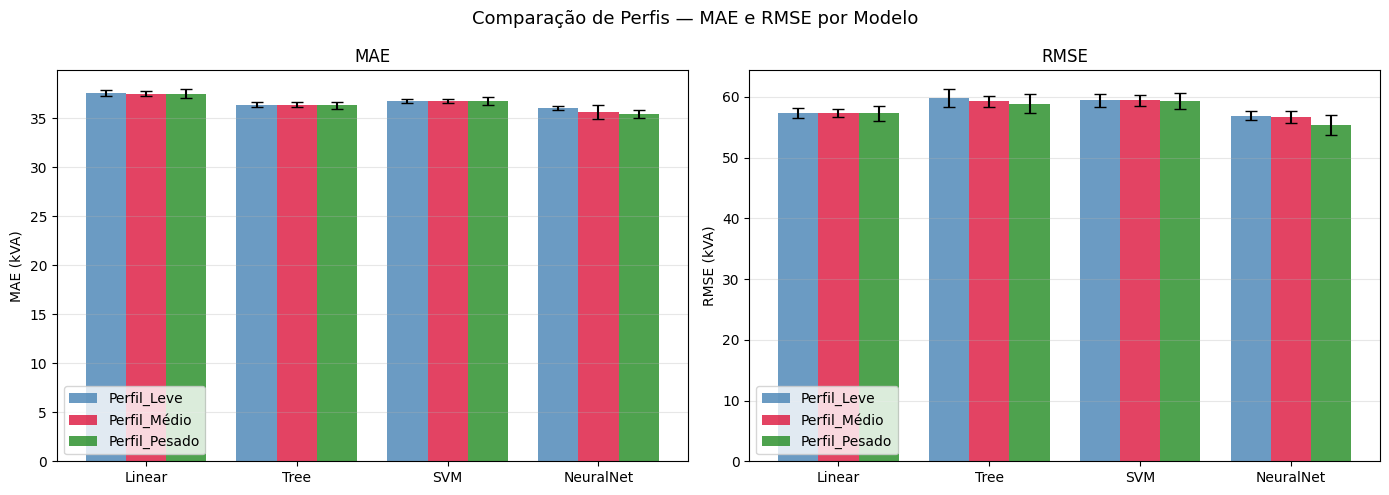

In [ ]:
models   = df_cmp['Modelo'].unique()
n_models = len(models)
x        = np.arange(n_models)
width    = 0.8 / len(PROFILES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de Perfis — MAE e RMSE por Modelo', fontsize=13)

for metric, ax in zip(['MAE', 'RMSE'], axes):
    for i, profile in enumerate(PROFILES):
        color  = colors.get(profile, 'gray')
        subset = df_cmp[df_cmp['Perfil'] == profile].set_index('Modelo')
        vals   = [subset.loc[m, metric]          for m in models]
        stds   = [subset.loc[m, f'{metric}_std'] for m in models]
        ax.bar(x + i * width, vals, width, yerr=stds, label=profile,
            color=color, alpha=0.8, capsize=4)

    ax.set_xticks(x + width * (len(PROFILES) - 1) / 2)
    ax.set_xticklabels(models)
    ax.set_ylabel(f'{metric} (kVA)')
    ax.set_title(metric)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

/tmp/ipykernel_9070/3183619370.py:21: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(lc['train_sizes'], train_mean, 'o-', color=color,
/tmp/ipykernel_9070/3183619370.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(lc['train_sizes'], val_mean,   'o-', color=color,


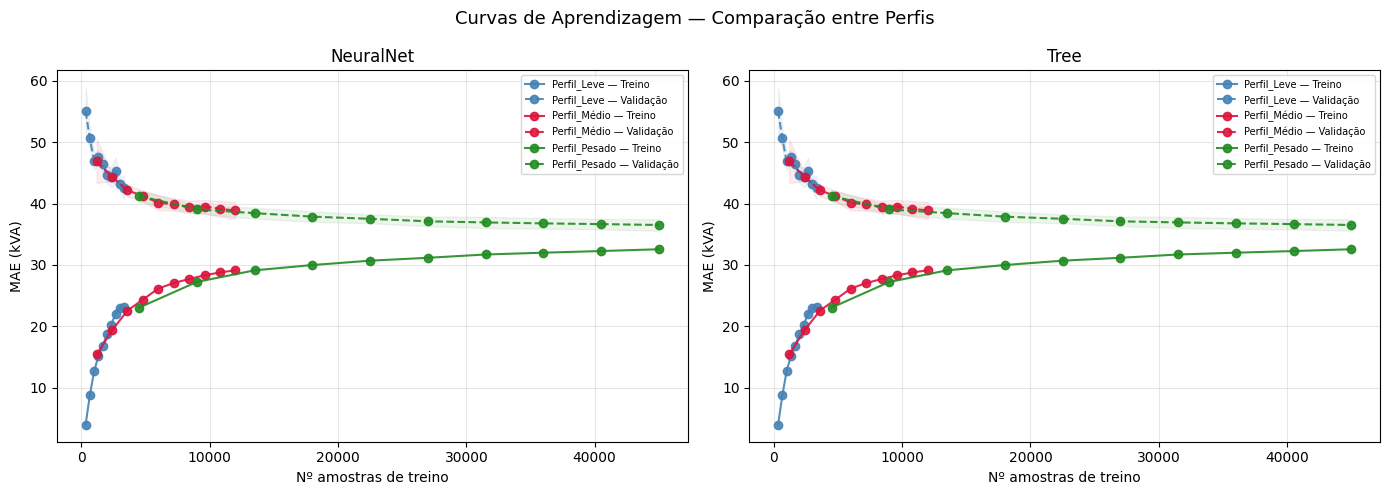

In [ ]:
all_models = list(curves_data[PROFILES[0]]['learning_curves'].keys())
fig, axes  = plt.subplots(1, len(all_models), figsize=(7 * len(all_models), 5))
fig.suptitle('Curvas de Aprendizagem — Comparação entre Perfis', fontsize=13)

if len(all_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, all_models):
    for profile in PROFILES:
        if profile not in curves_data:
            continue
        lc    = curves_data[profile]['learning_curves'].get(model_name)
        if lc is None:
            continue
        color       = colors.get(profile, 'gray')
        train_mean  = lc['train_mae'].mean(axis=1)
        train_std   = lc['train_mae'].std(axis=1)
        val_mean    = lc['val_mae'].mean(axis=1)
        val_std     = lc['val_mae'].std(axis=1)

        ax.plot(lc['train_sizes'], train_mean, 'o-', color=color,
                linestyle='-',  alpha=0.9, label=f'{profile} — Treino')
        ax.plot(lc['train_sizes'], val_mean,   'o-', color=color,
                linestyle='--', alpha=0.9, label=f'{profile} — Validação')
        ax.fill_between(lc['train_sizes'],
                        val_mean - val_std, val_mean + val_std,
                        alpha=0.08, color=color)

    ax.set_title(model_name)
    ax.set_xlabel('Nº amostras de treino')
    ax.set_ylabel('MAE (kVA)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() #TODO: legenda melhor onegaishimasu

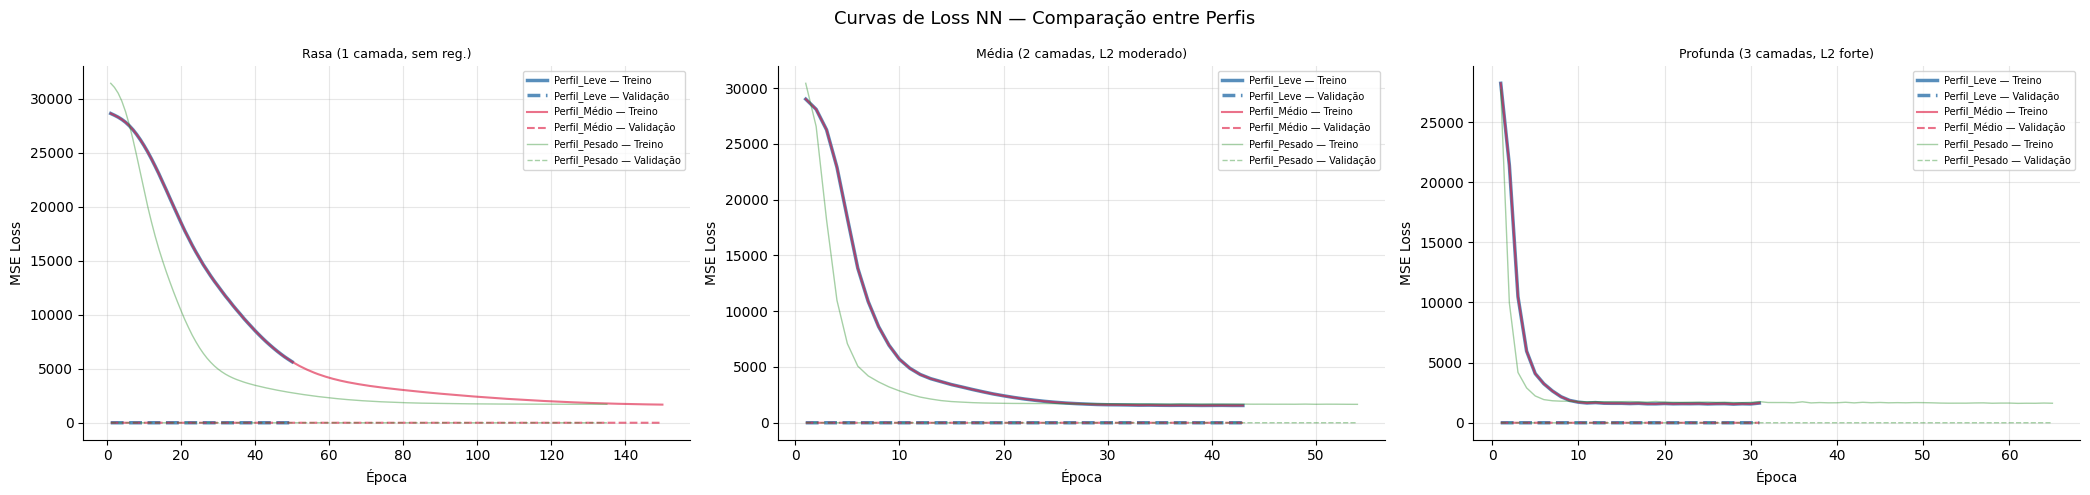

In [ ]:
nn_configs_names = [lc['name'] for lc in curves_data[PROFILES[0]]['loss_curves']]

fig, axes = plt.subplots(1, len(nn_configs_names), figsize=(7 * len(nn_configs_names), 5))
fig.suptitle('Curvas de Loss NN — Comparação entre Perfis', fontsize=13)
if len(nn_configs_names) == 1:
    axes = [axes]

for ax, cfg_name in zip(axes, nn_configs_names):
    for profile, style in zip(PROFILES, line_styles):
        if profile not in curves_data:
            continue
        lc = next((l for l in curves_data[profile]['loss_curves'] if l['name'] == cfg_name), None)
        if lc is None:
            continue

        color      = colors.get(profile, 'gray')
        epochs     = range(1, len(lc['train_loss']) + 1)
        val_epochs = range(1, len(lc['val_loss'])   + 1)

        ax.plot(epochs,     lc['train_loss'],
                color=color, linestyle='-',  label=f'{profile} — Treino', **style)
        ax.plot(val_epochs, [-v for v in lc['val_loss']],
                color=color, linestyle='--', label=f'{profile} — Validação', **style)

    ax.set_title(cfg_name, fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Comparação de Classificação entre Perfis

In [ ]:
# Carregar results_clf por perfil
clf_data = {}
for profile in PROFILES:
    path = os.path.join(RESULTS_DIR, profile, 'results_clf.pkl')
    with open(path, 'rb') as f:
        clf_data[profile] = pickle.load(f)


In [ ]:
# Tabela comparativa: métricas globais de classificação
rows_clf = []
for profile, res_clf in clf_data.items():
    for model_name, res in res_clf.items():
        rows_clf.append({
            'Perfil':           profile,
            'Modelo':           model_name,
            'Accuracy':         res['Accuracy_mean'],
            'Accuracy_std':     res['Accuracy_std'],
            'Precision':        res['Precision_mean'],
            'Precision_std':    res['Precision_std'],
            'Recall':           res['Recall_mean'],
            'Recall_std':       res['Recall_std'],
            'F1':               res['F1_mean'],
            'F1_std':           res['F1_std'],
        })

df_clf_cmp = pd.DataFrame(rows_clf)
print("COMPARAÇÃO DE PERFIS — CLASSIFICAÇÃO (Accuracy e F1)")
print(df_clf_cmp[['Perfil', 'Modelo', 'Accuracy', 'Accuracy_std', 'F1', 'F1_std']]
      .to_string(index=False, float_format='%.4f'))


COMPARAÇÃO DE PERFIS — CLASSIFICAÇÃO (Accuracy e F1)
       Perfil        Modelo  Accuracy  Accuracy_std     F1  F1_std
  Perfil_Leve Decision_Tree    0.6136        0.0119 0.6038  0.0130
  Perfil_Leve     NeuralNet    0.6534        0.0067 0.6169  0.0170
  Perfil_Leve           SVM    0.6158        0.0041 0.5305  0.0064
  Perfil_Leve           KNN    0.5916        0.0066 0.5679  0.0097
 Perfil_Médio Decision_Tree    0.6449        0.0123 0.6313  0.0114
 Perfil_Médio     NeuralNet    0.6672        0.0088 0.6482  0.0091
 Perfil_Médio           SVM    0.6238        0.0061 0.5422  0.0080
 Perfil_Médio           KNN    0.6360        0.0065 0.6132  0.0076
Perfil_Pesado Decision_Tree    0.6605        0.0055 0.6443  0.0047
Perfil_Pesado     NeuralNet    0.6785        0.0051 0.6623  0.0044
Perfil_Pesado           SVM    0.6220        0.0074 0.5398  0.0103
Perfil_Pesado           KNN    0.6605        0.0042 0.6401  0.0046


In [ ]:
# Diferença entre perfis (Médio − Leve), valores negativos = Médio melhor
if len(PROFILES) >= 2:
    p1_clf = df_clf_cmp[df_clf_cmp['Perfil'] == PROFILES[0]].set_index('Modelo')
    p2_clf = df_clf_cmp[df_clf_cmp['Perfil'] == PROFILES[1]].set_index('Modelo')

    diff_clf = pd.DataFrame({
        'Δ Accuracy':  p2_clf['Accuracy'] - p1_clf['Accuracy'],
        'Δ Precision': p2_clf['Precision'] - p1_clf['Precision'],
        'Δ Recall':    p2_clf['Recall']    - p1_clf['Recall'],
        'Δ F1':        p2_clf['F1']        - p1_clf['F1'],
    })
    print(f"\nDiferença ({PROFILES[1]} − {PROFILES[0]}), valores positivos = Médio melhor:")
    print(diff_clf.round(4).to_string())



Diferença (Perfil_Médio − Perfil_Leve), valores positivos = Médio melhor:
               Δ Accuracy  Δ Precision  Δ Recall    Δ F1
Modelo                                                  
Decision_Tree      0.0313       0.0274    0.0313  0.0275
NeuralNet          0.0138       0.0223    0.0138  0.0313
SVM                0.0080       0.0241    0.0080  0.0117
KNN                0.0444       0.0461    0.0444  0.0454


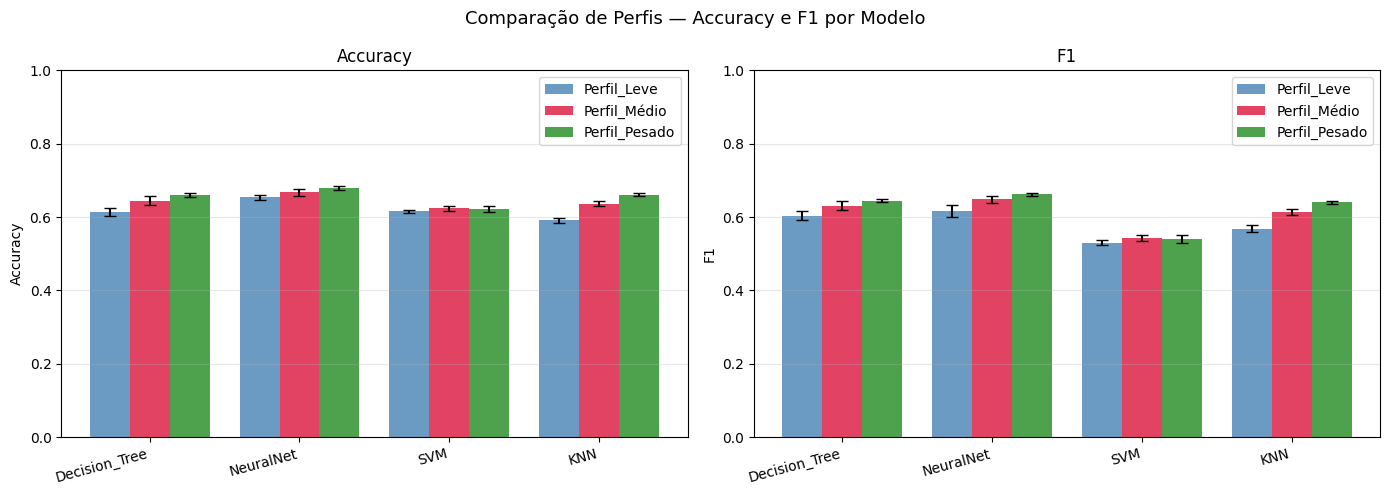

In [ ]:
# Gráfico de barras: Accuracy e F1 por modelo e perfil
models_clf = df_clf_cmp['Modelo'].unique()
n_models   = len(models_clf)
x          = np.arange(n_models)
width      = 0.8 / len(PROFILES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de Perfis — Accuracy e F1 por Modelo', fontsize=13)

for metric, ax in zip(['Accuracy', 'F1'], axes):
    for i, profile in enumerate(PROFILES):
        color  = colors.get(profile, 'gray')
        subset = df_clf_cmp[df_clf_cmp['Perfil'] == profile].set_index('Modelo')
        vals   = [subset.loc[m, metric]             for m in models_clf]
        stds   = [subset.loc[m, f'{metric}_std']    for m in models_clf]
        ax.bar(x + i * width, vals, width, yerr=stds, label=profile,
               color=color, alpha=0.8, capsize=4)

    ax.set_xticks(x + width * (len(PROFILES) - 1) / 2)
    ax.set_xticklabels(models_clf, rotation=15, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


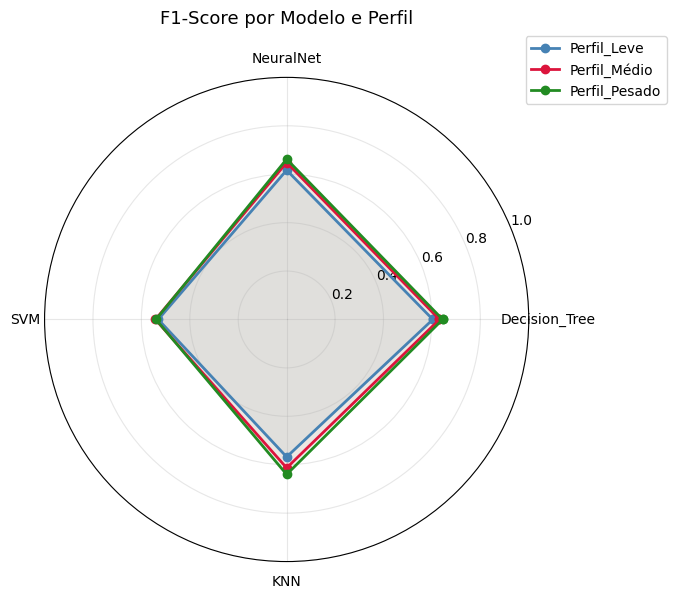

In [ ]:
# Radar chart: comparação de perfis por modelo (F1)
radar_models = df_clf_cmp['Modelo'].unique().tolist()
angles       = np.linspace(0, 2 * np.pi, len(radar_models), endpoint=False).tolist()
angles      += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_title('F1-Score por Modelo e Perfil', fontsize=13, pad=20)

for profile in PROFILES:
    color  = colors.get(profile, 'gray')
    subset = df_clf_cmp[df_clf_cmp['Perfil'] == profile].set_index('Modelo')
    vals   = [subset.loc[m, 'F1'] for m in radar_models] 
    vals  += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=profile, color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_models, fontsize=10)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Curvas de Loss NN na Classificação

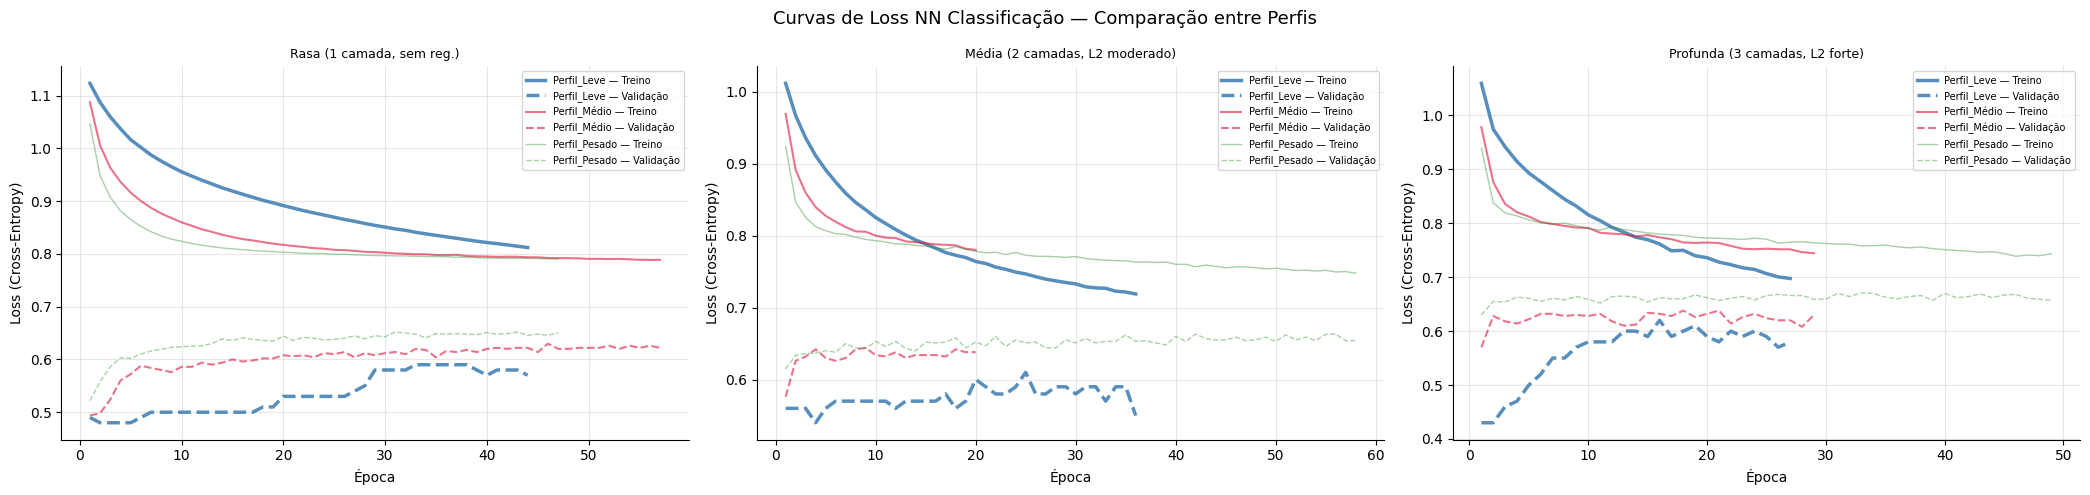

In [ ]:
# Curvas de Loss NN Classificação — Comparação entre Perfis
nn_clf_cfg_names = [lc['name'] for lc in curves_data[PROFILES[0]]['nn_loss_curves']]

fig, axes = plt.subplots(1, len(nn_clf_cfg_names),
                         figsize=(7 * len(nn_clf_cfg_names), 5))
fig.suptitle('Curvas de Loss NN Classificação — Comparação entre Perfis', fontsize=13)
if len(nn_clf_cfg_names) == 1:
    axes = [axes]

for ax, cfg_name in zip(axes, nn_clf_cfg_names):
    for profile, style in zip(PROFILES, line_styles):
        if profile not in curves_data:
            continue
        lc = next((l for l in curves_data[profile]['nn_loss_curves']
                   if l['name'] == cfg_name), None)
        if lc is None:
            continue

        color      = colors.get(profile, 'gray')
        epochs     = range(1, len(lc['train_loss']) + 1)
        val_epochs = range(1, len(lc['val_loss'])   + 1)

        ax.plot(epochs,     lc['train_loss'],
                color=color, linestyle='-',  label=f'{profile} — Treino', **style)
        ax.plot(val_epochs, lc['val_loss'],
                color=color, linestyle='--', label=f'{profile} — Validação', **style)

    ax.set_title(cfg_name, fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss (Cross-Entropy)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Curvas de Aprendizagem na Classificação

/tmp/ipykernel_9070/2250630383.py:24: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(lc['train_sizes'], train_mean, 'o-', color=color,
/tmp/ipykernel_9070/2250630383.py:26: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(lc['train_sizes'], val_mean,   'o-', color=color,


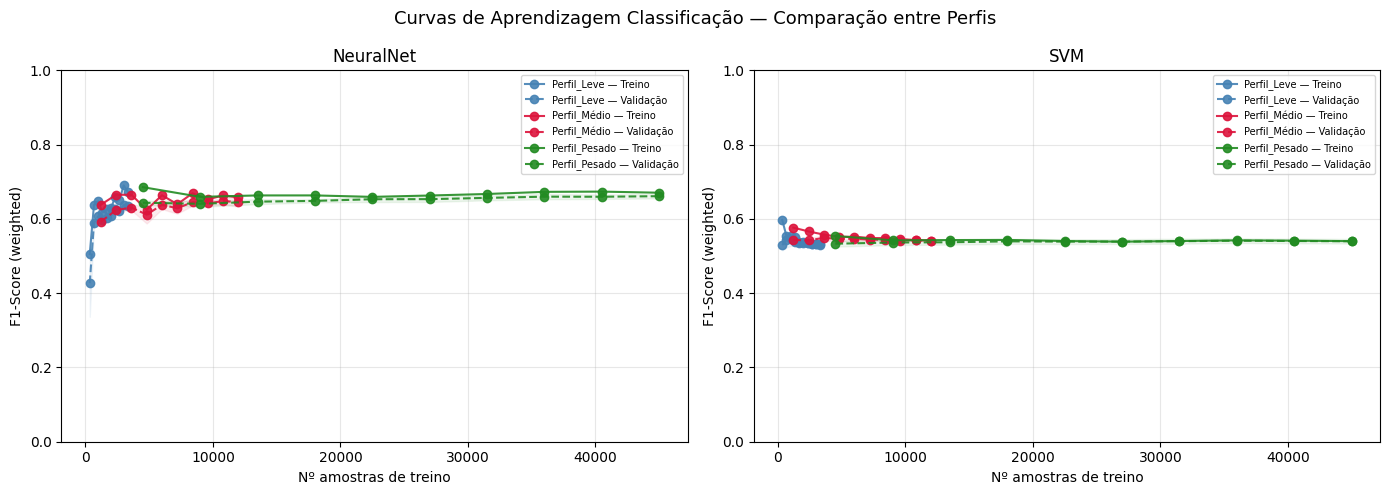

In [ ]:
# Curvas de Aprendizagem Classificação — Comparação entre Perfis
clf_lc_model_names = list(curves_data[PROFILES[0]]['nn_learning_curves'].keys())

fig, axes = plt.subplots(1, len(clf_lc_model_names),
                         figsize=(7 * len(clf_lc_model_names), 5))
fig.suptitle('Curvas de Aprendizagem Classificação — Comparação entre Perfis', fontsize=13)
if len(clf_lc_model_names) == 1:
    axes = [axes]

for ax, model_name in zip(axes, clf_lc_model_names):
    for profile in PROFILES:
        if profile not in curves_data:
            continue
        lc = curves_data[profile]['nn_learning_curves'].get(model_name)
        if lc is None:
            continue

        color      = colors.get(profile, 'gray')
        train_mean = lc['train_scores'].mean(axis=1)
        train_std  = lc['train_scores'].std(axis=1)
        val_mean   = lc['val_scores'].mean(axis=1)
        val_std    = lc['val_scores'].std(axis=1)

        ax.plot(lc['train_sizes'], train_mean, 'o-', color=color,
                linestyle='-',  alpha=0.9, label=f'{profile} — Treino')
        ax.plot(lc['train_sizes'], val_mean,   'o-', color=color,
                linestyle='--', alpha=0.9, label=f'{profile} — Validação')
        ax.fill_between(lc['train_sizes'],
                        val_mean - val_std, val_mean + val_std,
                        alpha=0.08, color=color)

    ax.set_title(model_name)
    ax.set_xlabel('Nº amostras de treino')
    ax.set_ylabel('F1-Score (weighted)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
